In [1]:
import sys

assert sys.version_info >= (3, 7)


In [2]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

In [3]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1" 

import tf_keras


In [4]:
import tensorflow as tf

assert version.parse(tf.__version__) >= version.parse("2.8.0")

In [5]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

In [6]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "generative"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

In [7]:
import numpy as np

In [8]:
import random

In [9]:
import os
from pathlib import Path
import numpy as np
from PIL import Image
from skimage.transform import resize

In [10]:
import os
import numpy as np
from PIL import Image
from pathlib import Path
from sklearn.model_selection import train_test_split

## Define paths:

In [11]:
os.getcwd()

'/Users/stephanehess/Documents/CAS_AML/dias_digit_project/project'

In [12]:
root_path = Path('/Users/stephanehess/Documents/CAS_AML/dias_digit_project/project')

In [13]:
image_dir_1 = root_path/"../data_1"

In [14]:
image_dir_1

PosixPath('/Users/stephanehess/Documents/CAS_AML/dias_digit_project/project/../data_1')

## Load and process all images:

In [15]:
def load_process_images(image_dir, validation_split=0.2):
    image_arrays = []
    image_identifiers = []

    # Determine the smallest square size
    target_size = None
    for image_path in Path(image_dir).glob("*.tif"):
        try:
            with Image.open(image_path) as img:
                width, height = img.size
                min_dim = min(width, height)
                if target_size is None or min_dim < target_size:
                    target_size = min_dim
        except Exception as e:
            print(f"Error determining size for {image_path}: {e}")

    if target_size is None:
        raise ValueError("No valid images found in the directory.")

    # Process and resize all images
    for image_path in Path(image_dir).glob("*.tif"):
        try:
            with Image.open(image_path) as img:
                # Convert to grayscale
                img = img.convert("L")  # 'L' mode ensures single-channel grayscale

                # Extract dimensions
                width, height = img.size

                # Calculate cropping box to center the crop
                top = (height - target_size) // 2
                left = (width - target_size) // 2
                bottom = top + target_size
                right = left + target_size

                # Crop and resize the image to ensure square dimensions
                img_cropped = img.crop((left, top, right, bottom))
                img_resized = img_cropped.resize((target_size, target_size))
                
                # Convert to numpy array and append to list
                image_arrays.append(np.array(img_resized))
                
                
                # Extract identifier from the last three characters of the file name
                identifier = image_path.stem[-3:]
                image_identifiers.append(identifier)

        except Exception as e:
            print(f"Error processing {image_path}: {e}")

    # Convert to numpy array (all images are guaranteed to have the same size)
    image_arrays = np.array(image_arrays)

    # Shuffle and split into training and validation sets
    data_indices = list(range(len(image_arrays)))
    random.shuffle(data_indices)

    val_count = int(len(image_arrays) * validation_split)
    val_indices = data_indices[:val_count]
    train_indices = data_indices[val_count:]

    train_data = image_arrays[train_indices]
    val_data = image_arrays[val_indices]

    train_identifiers = [image_identifiers[i] for i in train_indices]
    val_identifiers = [image_identifiers[i] for i in val_indices]

    return train_data, val_data, train_identifiers, val_identifiers

# Process images and split into training/validation sets
train_images, val_images, train_ids, val_ids = load_process_images(image_dir_1)

# Print shapes and identifiers
print(f"Training data shape: {train_images.shape}")
print(f"Validation data shape: {val_images.shape}")
print(f"Training identifiers: {train_ids}")
print(f"Validation identifiers: {val_ids}")



Training data shape: (89, 572, 572)
Validation data shape: (22, 572, 572)
Training identifiers: ['065', '052', '042', '089', '098', '017', '016', '053', '001', '056', '068', '059', '019', '027', '032', '014', '054', '048', '096', '057', '061', '010', '033', '074', '006', '108', '111', '094', '107', '005', '043', '064', '080', '103', '047', '051', '028', '088', '009', '062', '055', '075', '060', '041', '040', '073', '097', '106', '102', '069', '049', '030', '072', '039', '110', '070', '022', '095', '092', '037', '058', '031', '011', '067', '079', '015', '002', '082', '081', '021', '036', '020', '093', '085', '083', '018', '087', '004', '091', '034', '038', '044', '086', '007', '024', '023', '104', '003', '046']
Validation identifiers: ['090', '029', '099', '063', '066', '035', '076', '045', '012', '025', '101', '013', '105', '008', '077', '071', '078', '084', '026', '100', '109', '050']


In [16]:
type(train_images)

numpy.ndarray

In [17]:
train_images.shape

(89, 572, 572)

## Encode one single image as the simple most possible task (using dense network):

In [18]:
try_image = train_images[0:1]

In [19]:
try_image.shape

(1, 572, 572)

In [20]:
try_image[0]

array([[209, 208, 213, ..., 190, 191, 186],
       [211, 211, 214, ..., 194, 188, 187],
       [212, 215, 215, ..., 187, 189, 191],
       ...,
       [ 16,  26,  16, ...,  14,  13,  14],
       [ 14,  17,  17, ...,  16,  16,  16],
       [ 17,  16,  17, ...,  15,  15,  16]], dtype=uint8)

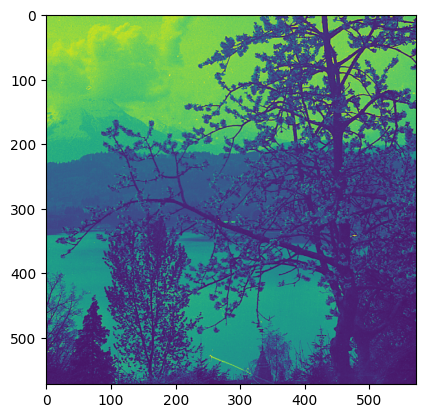

In [21]:
plt.imshow(try_image[0])

## Set image dimensions to be used in dense model:

In [22]:
min_dim = try_image.shape[1]
min_dim

572

In [23]:
tf.random.set_seed(42)  # extra code – ensures reproducibility on CPU

stacked_encoder = tf.keras.Sequential([
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(30, activation="relu"),
])
stacked_decoder = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(min_dim * min_dim),
    tf.keras.layers.Reshape([min_dim, min_dim])
])
stacked_ae = tf.keras.Sequential([stacked_encoder, stacked_decoder])

stacked_ae.compile(loss="mse", optimizer="nadam")                   
history = stacked_ae.fit(try_image, try_image, epochs=30,
                         validation_data=(try_image, try_image))

Epoch 1/30
1/1 [==============================] - 1s 828ms/step - loss: 14333.6592 - val_loss: 17746.9824
Epoch 2/30
1/1 [==============================] - 0s 149ms/step - loss: 17746.9824 - val_loss: 29407.1465
Epoch 3/30
1/1 [==============================] - 0s 141ms/step - loss: 29407.1465 - val_loss: 6959.4419
Epoch 4/30
1/1 [==============================] - 0s 150ms/step - loss: 6959.4419 - val_loss: 2636.8240
Epoch 5/30
1/1 [==============================] - 0s 142ms/step - loss: 2636.8240 - val_loss: 4154.8745
Epoch 6/30
1/1 [==============================] - 0s 148ms/step - loss: 4154.8745 - val_loss: 810.1337
Epoch 7/30
1/1 [==============================] - 0s 151ms/step - loss: 810.1337 - val_loss: 704.2502
Epoch 8/30
1/1 [==============================] - 0s 147ms/step - loss: 704.2502 - val_loss: 610.9504
Epoch 9/30
1/1 [==============================] - 0s 151ms/step - loss: 610.9504 - val_loss: 799.7198
Epoch 10/30
1/1 [==============================] - 0s 149ms/step -

1/1 [==============================] - 0s 54ms/step


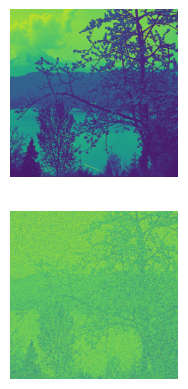

In [24]:
reconstructions = stacked_ae.predict(try_image[0:1])
plt.subplot(2, 1, 1)
plt.imshow(try_image[0])
plt.axis("off")
plt.subplot(2, 1, 2)
plt.imshow(reconstructions[0])
plt.axis("off")
plt.show()

In [25]:
stacked_ae.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (None, 30)                32721530  
                                                                 
 sequential_1 (Sequential)   (None, 572, 572)          33048684  
                                                                 
Total params: 65770214 (250.89 MB)
Trainable params: 65770214 (250.89 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [26]:
stacked_encoder.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 327184)            0         
                                                                 
 dense (Dense)               (None, 100)               32718500  
                                                                 
 dense_1 (Dense)             (None, 30)                3030      
                                                                 
Total params: 32721530 (124.82 MB)
Trainable params: 32721530 (124.82 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


## Find two similar images to make the task a bit more complicated:

In [29]:
idx_1 = train_ids.index('022')

In [30]:
idx_2 = train_ids.index('023')

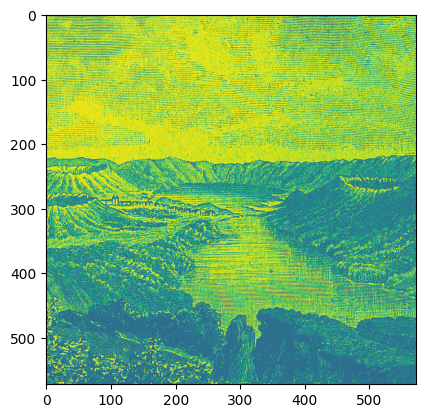

In [31]:
plt.imshow(train_images[idx_1])

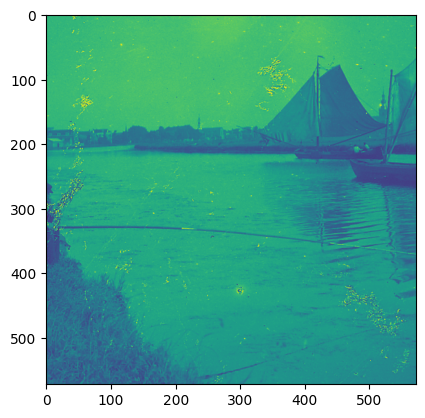

In [32]:
plt.imshow(train_images[idx_2])

In [33]:
similar_images_1 = np.array([train_images[idx_1], train_images[idx_2]])
similar_images_1.shape

(2, 572, 572)

In [34]:
tf.random.set_seed(42)  # extra code – ensures reproducibility on CPU

stacked_ae = tf.keras.Sequential([stacked_encoder, stacked_decoder])

stacked_ae.compile(loss="mse", optimizer="nadam")                   
history = stacked_ae.fit(similar_images_1, similar_images_1, epochs=30,
                         validation_data=(similar_images_1, similar_images_1))

Epoch 1/30
1/1 [==============================] - 1s 567ms/step - loss: 709238.6250 - val_loss: 14790.3691
Epoch 2/30
1/1 [==============================] - 0s 156ms/step - loss: 14790.3711 - val_loss: 5819.4980
Epoch 3/30
1/1 [==============================] - 0s 149ms/step - loss: 5819.4980 - val_loss: 3094.7974
Epoch 4/30
1/1 [==============================] - 0s 155ms/step - loss: 3094.7974 - val_loss: 1751.5354
Epoch 5/30
1/1 [==============================] - 0s 153ms/step - loss: 1751.5354 - val_loss: 1330.4452
Epoch 6/30
1/1 [==============================] - 0s 151ms/step - loss: 1330.4453 - val_loss: 1082.5734
Epoch 7/30
1/1 [==============================] - 0s 150ms/step - loss: 1082.5734 - val_loss: 915.3665
Epoch 8/30
1/1 [==============================] - 0s 151ms/step - loss: 915.3666 - val_loss: 885.8165
Epoch 9/30
1/1 [==============================] - 0s 150ms/step - loss: 885.8165 - val_loss: 970.0402
Epoch 10/30
1/1 [==============================] - 0s 147ms/step 

1/1 [==============================] - 0s 42ms/step
0
1


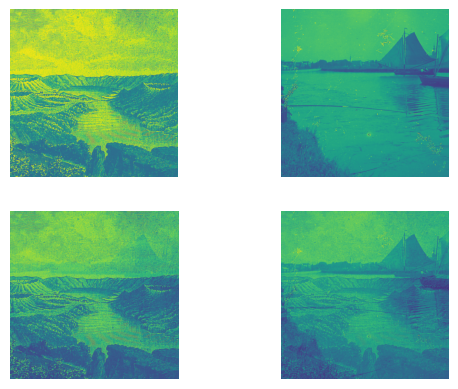

In [35]:
reconstructions = stacked_ae.predict(similar_images_1[0:2])
for image_idx in range(0, similar_images_1.shape[0]):
    print(image_idx)
    plt.subplot(2, 2, image_idx + 1)
    plt.imshow(similar_images_1[image_idx])
    plt.axis("off")
    plt.subplot(2, 2, image_idx + 2 + 1)
    plt.imshow(reconstructions[image_idx])
    plt.axis("off")
plt.show()

## Rebuild model with latent space of 300 and train:

In [45]:
tf.random.set_seed(42)  # extra code – ensures reproducibility on CPU

stacked_encoder = tf.keras.Sequential([
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(500, activation="relu"),
    tf.keras.layers.Dense(300, activation="relu"),
])
stacked_decoder = tf.keras.Sequential([
    tf.keras.layers.Dense(500, activation="relu"),
    tf.keras.layers.Dense(min_dim * min_dim),
    tf.keras.layers.Reshape([min_dim, min_dim])
])
stacked_ae = tf.keras.Sequential([stacked_encoder, stacked_decoder])

stacked_ae.compile(loss="mse", optimizer="nadam")                   
history = stacked_ae.fit(similar_images_1, similar_images_1, epochs=55,
                         validation_data=(similar_images_1, similar_images_1))

Epoch 1/55
1/1 [==============================] - 4s 4s/step - loss: 27496.4473 - val_loss: 2354176.7500
Epoch 2/55
1/1 [==============================] - 2s 2s/step - loss: 2354176.7500 - val_loss: 181839.6719
Epoch 3/55
1/1 [==============================] - 2s 2s/step - loss: 181839.6719 - val_loss: 1159053.1250
Epoch 4/55
1/1 [==============================] - 2s 2s/step - loss: 1159053.0000 - val_loss: 159229.4531
Epoch 5/55
1/1 [==============================] - 1s 1s/step - loss: 159229.4531 - val_loss: 49397.8750
Epoch 6/55
1/1 [==============================] - 1s 815ms/step - loss: 49397.8828 - val_loss: 52616.5625
Epoch 7/55
1/1 [==============================] - 2s 2s/step - loss: 52616.5625 - val_loss: 4676.7495
Epoch 8/55
1/1 [==============================] - 2s 2s/step - loss: 4676.7495 - val_loss: 1546.2070
Epoch 9/55
1/1 [==============================] - 1s 1s/step - loss: 1546.2070 - val_loss: 1622.4176
Epoch 10/55
1/1 [==============================] - 1s 1s/step -

1/1 [==============================] - 0s 71ms/step
0
1


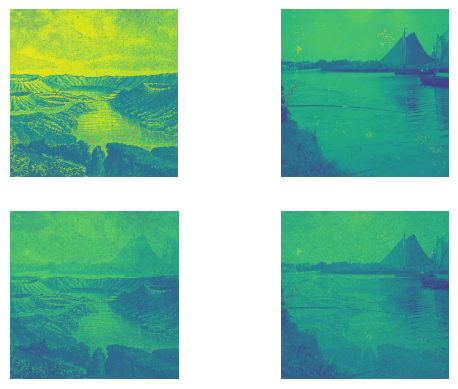

In [46]:
reconstructions = stacked_ae.predict(similar_images_1[0:2])
for image_idx in range(0, similar_images_1.shape[0]):
    print(image_idx)
    plt.subplot(2, 2, image_idx + 1)
    plt.imshow(similar_images_1[image_idx])
    plt.axis("off")
    plt.subplot(2, 2, image_idx + 2 + 1)
    plt.imshow(reconstructions[image_idx])
    plt.axis("off")
plt.show()

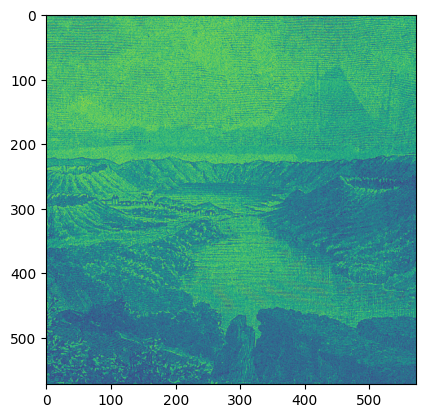

In [47]:
plt.imshow(reconstructions[0])

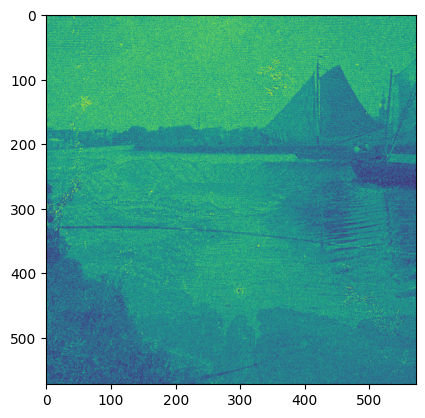

In [48]:
plt.imshow(reconstructions[1])

In [49]:
from sklearn.manifold import TSNE

similar_images_1_compressed = stacked_encoder.predict(similar_images_1)

1/1 [==============================] - 0s 47ms/step


In [50]:
type(similar_images_1_compressed)

numpy.ndarray

In [51]:
similar_images_1_compressed.shape

(2, 300)

In [52]:
#from sklearn.manifold import TSNE

#similar_images_1_compressed = stacked_encoder.predict(similar_images_1)
tsne = TSNE(perplexity= 1, init="pca", learning_rate="auto", random_state=42)
X_valid_2D = tsne.fit_transform(similar_images_1_compressed)

/var/folders/p2/j3lbpcl141q66c1kqyxwsc3w0000gn/T/ipykernel_97247/4084811815.py:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_valid_2D[:, 0], X_valid_2D[:, 1], s=10, cmap="tab10")


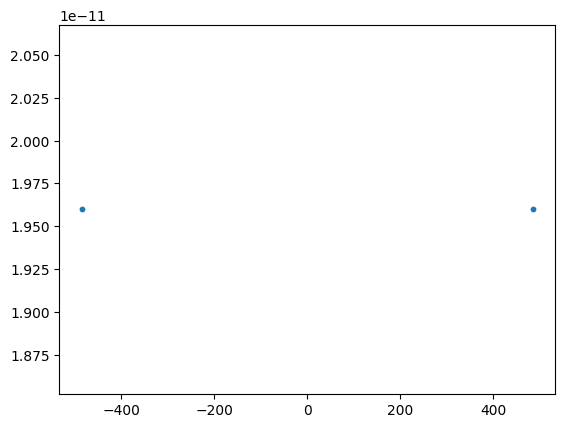

In [53]:
plt.scatter(X_valid_2D[:, 0], X_valid_2D[:, 1], s=10, cmap="tab10")
plt.show()

## Try the same with a convolutional neural network:

In [54]:
length_of_img_square = 572

In [55]:
similar_images_1 = similar_images_1.astype("float32") / 255.0

In [56]:
similar_images_1[0].shape

(572, 572)

In [57]:
similar_images_1.shape

(2, 572, 572)

In [58]:
from functools import partial

In [59]:
similar_images_1.shape

(2, 572, 572)

In [60]:
def crop_images(image_data, crop_size):
    """
    Crops images stored in a NumPy array to the specified size.
    
    Parameters:
        image_data (numpy.ndarray): The input image data of shape (n, m, m), where n is the number of images.
        crop_size (int): The desired dimension e for the cropped images (output shape will be (n, e, e)).
        
    Returns:
        numpy.ndarray: Cropped image data of shape (n, e, e).
    """
    n, m, _ = image_data.shape  # Get number of images and dimensions of each image
    e = crop_size  # Target size (e x e)
    
    if e >= m:
        raise ValueError("Crop size must be smaller than the original image size.")
    
    # Calculate cropping margins
    start = (m - e) // 2  # Start index for cropping
    end = start + e       # End index for cropping
    
    # Crop each image
    cropped_images = image_data[:, start:end, start:end]
    
    return cropped_images

In [61]:
9*3*4*4

432

In [62]:
desired_dim = 28

In [63]:
cropped_images = crop_images(similar_images_1, desired_dim)

In [64]:
cropped_images.shape

(2, 28, 28)

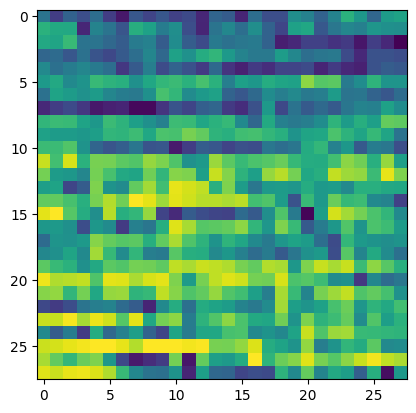

In [65]:
plt.imshow(cropped_images[0])

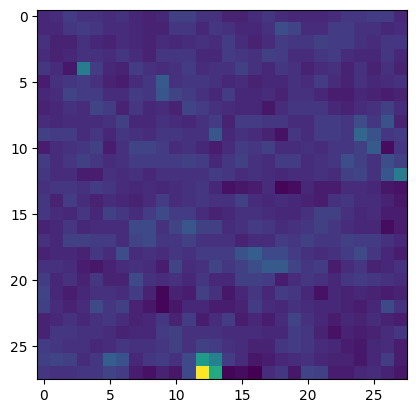

In [66]:
plt.imshow(cropped_images[1])

In [67]:
cropped_images = cropped_images.astype("float32") / 255.0

In [68]:
cropped_images.shape

(2, 28, 28)

In [69]:
fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist
X_train_full = X_train_full.astype(np.float32) / 255
X_test = X_test.astype(np.float32) / 255
X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

In [70]:
X_train.shape

(55000, 28, 28)

In [71]:
X_train_select = X_train[0:2].copy()
X_train_select.shape

(2, 28, 28)

In [72]:
X_valid.shape

(5000, 28, 28)

In [73]:
X_valid_select = X_valid[0:500].copy()

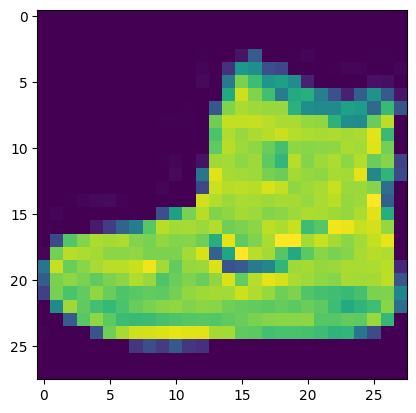

In [74]:
plt.imshow(X_train_select[0])

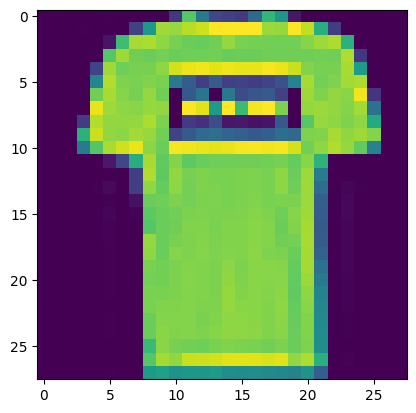

In [75]:
plt.imshow(X_train_select[1])

In [76]:
#experiment_data = cropped_images
experiment_data = X_train_select

tf.random.set_seed(42)  # extra code – ensures reproducibility on CPU

conv_encoder = tf.keras.Sequential([
    tf.keras.layers.Reshape([28, 28, 1]),
    tf.keras.layers.Conv2D(16, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPool2D(pool_size=2),  # output: 14 × 14 x 16
    tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPool2D(pool_size=2),  # output: 7 × 7 x 326
    tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPool2D(pool_size=2),  # output: 3 × 3 x 64
    tf.keras.layers.Conv2D(30, 3, padding="same", activation="relu"),
    tf.keras.layers.GlobalAvgPool2D()  # output: 30
])
conv_decoder = tf.keras.Sequential([
    tf.keras.layers.Dense(3 * 3 * 16),
    tf.keras.layers.Reshape((3, 3, 16)),
    tf.keras.layers.Conv2DTranspose(32, 3, strides=2, activation="relu"),
    tf.keras.layers.Conv2DTranspose(16, 3, strides=2, padding="same",
                                    activation="relu"),
    tf.keras.layers.Conv2DTranspose(1, 3, strides=2, padding="same"),
    tf.keras.layers.Reshape([28, 28])
])
conv_ae = tf.keras.Sequential([conv_encoder, conv_decoder])

# extra code – compiles and fits the model
conv_ae.compile(loss="mse", optimizer="nadam")
history = conv_ae.fit(experiment_data, experiment_data, epochs=10,
                      validation_data=(experiment_data, experiment_data))

Epoch 1/10
1/1 [==============================] - 1s 885ms/step - loss: 0.3193 - val_loss: 0.3169
Epoch 2/10
1/1 [==============================] - 0s 17ms/step - loss: 0.3169 - val_loss: 0.3140
Epoch 3/10
1/1 [==============================] - 0s 16ms/step - loss: 0.3140 - val_loss: 0.3098
Epoch 4/10
1/1 [==============================] - 0s 18ms/step - loss: 0.3098 - val_loss: 0.3029
Epoch 5/10
1/1 [==============================] - 0s 17ms/step - loss: 0.3029 - val_loss: 0.2912
Epoch 6/10
1/1 [==============================] - 0s 17ms/step - loss: 0.2912 - val_loss: 0.2716
Epoch 7/10
1/1 [==============================] - 0s 18ms/step - loss: 0.2716 - val_loss: 0.2426
Epoch 8/10
1/1 [==============================] - 0s 16ms/step - loss: 0.2426 - val_loss: 0.2107
Epoch 9/10
1/1 [==============================] - 0s 17ms/step - loss: 0.2107 - val_loss: 0.1891
Epoch 10/10
1/1 [==============================] - 0s 16ms/step - loss: 0.1891 - val_loss: 0.1716


In [77]:
reconstructions = conv_ae.predict(X_train_select)

1/1 [==============================] - 0s 69ms/step


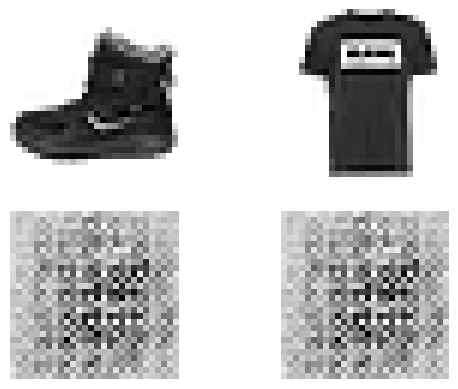

In [78]:
for image_idx in range(0, experiment_data.shape[0]):
    #print(image_idx)
    plt.subplot(2, experiment_data.shape[0], image_idx + 1)
    plt.imshow(experiment_data[image_idx], cmap="binary")
    plt.axis("off")
    plt.subplot(2, experiment_data.shape[0], image_idx + experiment_data.shape[0] + 1)
    plt.imshow(reconstructions[image_idx], cmap="binary")
    plt.axis("off")
plt.show()

In [79]:
stacked_encoder.summary()

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_2 (Flatten)         (None, 327184)            0         
                                                                 
 dense_8 (Dense)             (None, 500)               163592500 
                                                                 
 dense_9 (Dense)             (None, 300)               150300    
                                                                 
Total params: 163742800 (624.63 MB)
Trainable params: 163742800 (624.63 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [80]:
conv_encoder.summary()

Model: "sequential_10"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 reshape_3 (Reshape)         (None, 28, 28, 1)         0         
                                                                 
 conv2d (Conv2D)             (None, 28, 28, 16)        160       
                                                                 
 max_pooling2d (MaxPooling2  (None, 14, 14, 16)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 14, 14, 32)        4640      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 7, 7, 32)          0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 7, 7, 64)        

In [81]:
conv_decoder.summary()

Model: "sequential_11"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_12 (Dense)            (None, 144)               4464      
                                                                 
 reshape_4 (Reshape)         (None, 3, 3, 16)          0         
                                                                 
 conv2d_transpose (Conv2DTr  (None, 7, 7, 32)          4640      
 anspose)                                                        
                                                                 
 conv2d_transpose_1 (Conv2D  (None, 14, 14, 16)        4624      
 Transpose)                                                      
                                                                 
 conv2d_transpose_2 (Conv2D  (None, 28, 28, 1)         145       
 Transpose)                                                      
                                                     

In [82]:
conv_ae.summary()

Model: "sequential_12"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_10 (Sequential)  (None, 30)                40606     
                                                                 
 sequential_11 (Sequential)  (None, 28, 28)            13873     
                                                                 
Total params: 54479 (212.81 KB)
Trainable params: 54479 (212.81 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


## Use larger data set to showcase that the convolutional network needs training to adequately encode images:

In [83]:

tf.random.set_seed(42)  # extra code – ensures reproducibility on CPU

conv_encoder = tf.keras.Sequential([
    tf.keras.layers.Reshape([28, 28, 1]),
    tf.keras.layers.Conv2D(16, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPool2D(pool_size=2),  # output: 14 × 14 x 16
    tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPool2D(pool_size=2),  # output: 7 × 7 x 326
    tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPool2D(pool_size=2),  # output: 3 × 3 x 64
    tf.keras.layers.Conv2D(30, 3, padding="same", activation="relu"),
    tf.keras.layers.GlobalAvgPool2D()  # output: 30
])
conv_decoder = tf.keras.Sequential([
    tf.keras.layers.Dense(3 * 3 * 16),
    tf.keras.layers.Reshape((3, 3, 16)),
    tf.keras.layers.Conv2DTranspose(32, 3, strides=2, activation="relu"),
    tf.keras.layers.Conv2DTranspose(16, 3, strides=2, padding="same",
                                    activation="relu"),
    tf.keras.layers.Conv2DTranspose(1, 3, strides=2, padding="same"),
    tf.keras.layers.Reshape([28, 28])
])
conv_ae = tf.keras.Sequential([conv_encoder, conv_decoder])

# extra code – compiles and fits the model
conv_ae.compile(loss="mse", optimizer="nadam")
history = conv_ae.fit(X_train, X_train, epochs=10,
                      validation_data=(X_valid_select, X_valid_select))

Epoch 1/10
1719/1719 [==============================] - 17s 10ms/step - loss: 0.0332 - val_loss: 0.0252
Epoch 2/10
1719/1719 [==============================] - 17s 10ms/step - loss: 0.0212 - val_loss: 0.0204
Epoch 3/10
1719/1719 [==============================] - 16s 9ms/step - loss: 0.0181 - val_loss: 0.0190
Epoch 4/10
1719/1719 [==============================] - 16s 9ms/step - loss: 0.0163 - val_loss: 0.0160
Epoch 5/10
1719/1719 [==============================] - 17s 10ms/step - loss: 0.0152 - val_loss: 0.0150
Epoch 6/10
1719/1719 [==============================] - 17s 10ms/step - loss: 0.0144 - val_loss: 0.0143
Epoch 7/10
1719/1719 [==============================] - 16s 10ms/step - loss: 0.0137 - val_loss: 0.0139
Epoch 8/10
1719/1719 [==============================] - 16s 9ms/step - loss: 0.0131 - val_loss: 0.0132
Epoch 9/10
1719/1719 [==============================] - 16s 9ms/step - loss: 0.0127 - val_loss: 0.0134
Epoch 10/10
1719/1719 [==============================] - 15s 9ms/ste

In [84]:
reconstructions = conv_ae.predict(X_train_select)

1/1 [==============================] - 0s 73ms/step


In [85]:
reconstructions.shape

(2, 28, 28)

In [86]:
X_train_select.shape

(2, 28, 28)

In [87]:
X_train_select.shape[0]

2

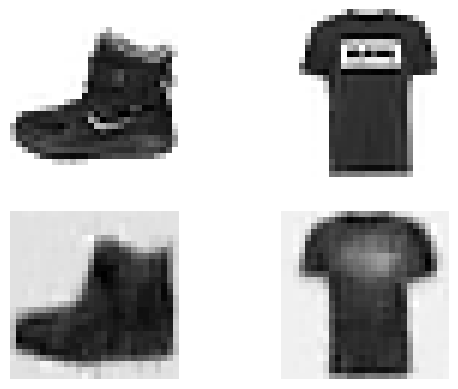

In [88]:

for image_idx in range(0, X_train_select.shape[0]):
    #print(image_idx)
    plt.subplot(2, X_train_select.shape[0], image_idx + 1)
    plt.imshow(X_train_select[image_idx], cmap="binary")
    plt.axis("off")
    plt.subplot(2, X_train_select.shape[0], image_idx + X_train_select.shape[0] + 1)
    plt.imshow(reconstructions[image_idx], cmap="binary")
    plt.axis("off")
plt.show()

In [89]:
plot_reconstructions(conv_ae, images=X_train_select, n_images=12)

NameError: name 'plot_reconstructions' is not defined

In [ ]:


tf.random.set_seed(42)  # extra code – ensures reproducibility on CPU¨


#DefaultConv2D = partial(tf.keras.layers.Conv2D, kernel_size = 3, padding='same', 
 #                       activation = 'relu', kernel_initializer='he_normal')

conv_encoder = tf.keras.Sequential([
    tf.keras.layers.Reshape([desired_dim, desired_dim, 1]),
    tf.keras.layers.Conv2D(16, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPool2D(pool_size=4),  
    tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPool2D(pool_size=4),  
    tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPool2D(pool_size=3),  
    tf.keras.layers.Conv2D(64, 9, padding="same", activation="relu"),
    tf.keras.layers.GlobalAvgPool2D()  # output: 30
])
conv_decoder = tf.keras.Sequential([
    tf.keras.layers.Dense(9 * 9 * 16),
    tf.keras.layers.Reshape((9, 9, 16)),
    tf.keras.layers.Conv2DTranspose(32, 3, strides=3, activation="relu"),
    tf.keras.layers.Conv2DTranspose(16, 3, strides=4, padding="same",
                                    activation="relu"),
    tf.keras.layers.Conv2DTranspose(1, 3, strides=4, padding="same"),
    tf.keras.layers.Reshape([desired_dim, desired_dim])
])
conv_ae = tf.keras.Sequential([conv_encoder, conv_decoder])

# extra code – compiles and fits the model
conv_ae.compile(loss="mse", optimizer="nadam")
history = conv_ae.fit(cropped_images, cropped_images, epochs=30,
                      validation_data=(cropped_images, cropped_images))

## Putative formula for calculating outputs of hidden layers:

In [ ]:
conv_encoder.summary()

In [ ]:
conv_decoder.summary()

In [ ]:
conv_ae.summary()

In [ ]:
reconstructions = conv_ae.predict(cropped_images[0:2])

In [ ]:
type(reconstructions)

In [ ]:
reconstructions.shape

In [ ]:
plt.imshow(reconstructions[0])

In [ ]:
reconstructions = conv_ae.predict(cropped_images[0:2])
for image_idx in range(0, cropped_images.shape[0]):
    print(image_idx)
    plt.subplot(2, 2, image_idx + 1)
    plt.imshow(cropped_images[image_idx], cmap="binary")
    plt.axis("off")
    plt.subplot(2, 2, image_idx + 2 + 1)
    plt.imshow(reconstructions[image_idx], cmap="binary")
    plt.axis("off")
plt.show()

In [ ]:
reconstructions

In [ ]:
fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist
X_train_full = X_train_full.astype(np.float32) / 255
X_test = X_test.astype(np.float32) / 255
X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

In [ ]:
X_train.shape

In [ ]:
X_train[0].shape

In [ ]:
import numpy as np

def plot_reconstructions(model, images=X_valid, n_images=5):
    reconstructions = np.clip(model.predict(images[:n_images]), 0, 1)
    fig = plt.figure(figsize=(n_images * 1.5, 3))
    for image_index in range(n_images):
        plt.subplot(2, n_images, 1 + image_index)
        plt.imshow(images[image_index], cmap="binary")
        plt.axis("off")
        plt.subplot(2, n_images, 1 + n_images + image_index)
        plt.imshow(reconstructions[image_index], cmap="binary")
        plt.axis("off")

In [ ]:
tf.random.set_seed(42)  # extra code – ensures reproducibility on CPU

conv_encoder = tf.keras.Sequential([
    tf.keras.layers.Reshape([28, 28, 1]),
    tf.keras.layers.Conv2D(16, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPool2D(pool_size=2),  # output: 14 × 14 x 16
    tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPool2D(pool_size=2),  # output: 7 × 7 x 326
    tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPool2D(pool_size=2),  # output: 3 × 3 x 64
    tf.keras.layers.Conv2D(30, 3, padding="same", activation="relu"),
    tf.keras.layers.GlobalAvgPool2D()  # output: 30
])
conv_decoder = tf.keras.Sequential([
    tf.keras.layers.Dense(3 * 3 * 16),
    tf.keras.layers.Reshape((3, 3, 16)),
    tf.keras.layers.Conv2DTranspose(32, 3, strides=2, activation="relu"),
    tf.keras.layers.Conv2DTranspose(16, 3, strides=2, padding="same",
                                    activation="relu"),
    tf.keras.layers.Conv2DTranspose(1, 3, strides=2, padding="same"),
    tf.keras.layers.Reshape([28, 28])
])
conv_ae = tf.keras.Sequential([conv_encoder, conv_decoder])

# extra code – compiles and fits the model
conv_ae.compile(loss="mse", optimizer="nadam")
history = conv_ae.fit(X_train, X_train, epochs=10,
                      validation_data=(X_valid, X_valid))


In [ ]:
plot_reconstructions(conv_ae)
plt.show()

In [ ]:
plt.imshow(X_train[0], cmap="binary")

In [ ]:
X_valid.shape

In [ ]:
import numpy as np

def plot_reconstructions(model, images=X_valid, n_images=5):
    reconstructions = np.clip(model.predict(images[:n_images]), 0, 1)
    fig = plt.figure(figsize=(n_images * 1.5, 3))
    for image_index in range(n_images):
        plt.subplot(2, n_images, 1 + image_index)
        plt.imshow(images[image_index], cmap="binary")
        plt.axis("off")
        plt.subplot(2, n_images, 1 + n_images + image_index)
        plt.imshow(reconstructions[image_index], cmap="binary")
        plt.axis("off")

plot_reconstructions(stacked_ae)
save_fig("reconstruction_plot")  # extra code – saves the high res figure
plt.show()

In [ ]:
from sklearn.manifold import TSNE

X_valid_compressed = stacked_encoder.predict(X_valid)
tsne = TSNE(init="pca", learning_rate="auto", random_state=42)
X_valid_2D = tsne.fit_transform(X_valid_compressed)


In [ ]:
plt.scatter(X_valid_2D[:, 0], X_valid_2D[:, 1], c=y_valid, s=10, cmap="tab10")
plt.show()